In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import os
import glob
import shutil

import xarray as xr
import numpy as np
from pyhomogenize import open_xrdataset
import seaborn as sns
#
from cmcrameri import cm
from cdo import *
cdo = Cdo()  
cdo.forceOutput = True
forceCDO = True

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [3]:
from plotting_tools_snow import *

In [4]:
import dask
from dask.distributed import Client
import scipy.stats as sts
import xarray as xr
import dask
from pyhomogenize import open_xrdataset, save_xrdataset

Data is available here:
https://doi.org/10.5281/zenodo.18495851

copy into tmpdir , see below

In [5]:
home=os.getcwd()
# The data is quite large, therefore I use my work
database='/work/ch0636/g300047/SNOW-RESEARCH/HORIZONTAL'

# In the next two boxes you have to make a decision what you like to plot

In [6]:
# set directories for SNOWDAY
var='sd'
datadir=database+'/SNOWDAY-YEAR/'
outdatadir=database+'/SNOWDAY-timeslice/'
tmpdir=database+'/tmp/'
plotdir=database+'/plots/HORIZONTAL-SD-test/'

In [17]:
# set directories for SNW
var='snw'
datadir=database+'/SNW-YEAR/'
outdatadir=database+'/SNW-timeslice/'
tmpdir=database+'/tmp-snw/'
plotdir=database+'/plots/HORIZONTAL-SNW-test/'

## files are not always replace it seems, better delete outdatadir before running

In [7]:
directory_available(outdatadir)
directory_available(plotdir)

Grid:

In [8]:
print('home: ',home)
griddir=home.replace('plotting-py/HORIZONTAL','grid')
grid=home.replace('plotting-py/HORIZONTAL','grid/EUR11-grid.txt')
griddir

home:  /home/g/g300047/SCRIPTS/github/snow-research/plotting_py/HORIZONTAL


'/home/g/g300047/SCRIPTS/github/snow-research/plotting_py/HORIZONTAL'

In [9]:
sims = glob.glob(tmpdir+'*.nc')
#sims

## Regridding
CNRM, ICTP, MPI-CSC:
Three regional climate simulation have not been provide on the regular EURO-CORDEX $0.11^\circ $ grid and had to be remapped. ALADIN63 and RegCM4-6 are remapped by using the CDO remapping method \textit{remapcon}. MPI-CSC-REMO2009 is on a shiftet EURO-CORDEX grid and is moved with \textit{cdo set grid} to the standard EURO-CORDEX $ 0.11^\circ $ grid.

### If you have conducted remapping, you do not need to do it again , files are saved

In [10]:
sims_remaped=glob.glob(datadir+'*rcp85*.nc')
#sims_remaped

Only run the next routine once, it takes a long time 

### Colors for snow days

In [11]:
#snowday-absolut

level_steps=[0,1,30,60,90,120,150,180,210,240]

colors_absolute =["white",plt.get_cmap("YlGnBu")(0.1),
                    plt.get_cmap("YlGnBu")(0.25),
                    plt.get_cmap("YlGnBu")(0.4),
                    plt.get_cmap("YlGnBu")(0.55),
                    plt.get_cmap("YlGnBu")(0.7),
                    plt.get_cmap("YlGnBu")(0.85),
                    plt.get_cmap("YlGnBu")(1.0),
                    plt.get_cmap("PRGn")(0.1),
                    plt.get_cmap("PRGn")(0.2)]

color_steps = ListedColormap(colors_absolute)
color_steps.set_bad(color="lightgrey")

# difference snowday
level_steps_diff=[-120,-90,-75,-60,-45,-30,-15,0,15]
colors_diff = ['#3f007d',
               '#081d58',
               '#253494',
               '#225ea8',
               '#1d91c0',
               '#41b6c4',
               '#7fcdbb',
               '#c7e9b4',
               '#edf8b1',
               '#ffffff']
               #'#f0f0f0']

colors_diff_cmap = ListedColormap(colors_diff)
colors_diff_cmap.set_bad(color="lightgrey")

#color_steps.set_under(color="white")

### Colors for snw

In [18]:
# von Christian
# Levels and colormap for snow water equivalent [mm]
from cmocean.cm import ice_r, matter

levels_cm_swe = {
    "levels": np.array([0.0, 5.0, 10.0, 20.0, 30.0, 40.0, 60.0, 80.0, 100.0,
                        140.0, 180.0, 220.0, 260.0, 300.0]),
    "ticks": np.array([0, 5, 10, 20, 30, 40, 60, 80, 100,
                       140, 180, 220, 260, 300]),
    "cm": ListedColormap(
        ["white",
         ice_r(0.1),
         ice_r(0.2),
         ice_r(0.3),
         ice_r(0.4),
         ice_r(0.5),
         ice_r(0.6),
         ice_r(0.7),
         ice_r(0.8),
         ice_r(0.9),
         matter(0.9),
         matter(0.8),
         matter(0.7),
         matter(0.6)])
}
levels_cm_swe["cm"].set_bad(color="lightgrey")


In [13]:
levels_cm_swe

{'levels': array([  0.,   5.,  10.,  20.,  30.,  40.,  60.,  80., 100., 140., 180.,
        220., 260., 300.]),
 'ticks': array([  0,   5,  10,  20,  30,  40,  60,  80, 100, 140, 180, 220, 260,
        300]),
 'cm': <matplotlib.colors.ListedColormap at 0x7ffad4721490>}

In [19]:
#snw-diff
level_snw_steps_diff=[-150,-100,-50,-40,-30,-20,-10,-5,0]
colors_snw_diff = ['#3f007d',
               '#081d58',
               '#253494',
               '#225ea8',
               '#1d91c0',
               '#41b6c4',
               '#7fcdbb',
               '#c7e9b4',
               '#edf8b1',
               '#ffffff']
               #'#f0f0f0']

colors_snw_diff_cmap = ListedColormap(colors_snw_diff)
colors_snw_diff_cmap.set_bad(color="lightgrey")

#color_steps.set_under(color="white")

2021-2050
Plot saved: /work/ch0636/g300047/SNOW-RESEARCH/HORIZONTAL/plots/HORIZONTAL-SNW-test//ensemble_mean_diff_snw_ensemble_diff_2021-2050.png
2069-2098
Plot saved: /work/ch0636/g300047/SNOW-RESEARCH/HORIZONTAL/plots/HORIZONTAL-SNW-test//ensemble_mean_diff_snw_ensemble_diff_2069-2098.png


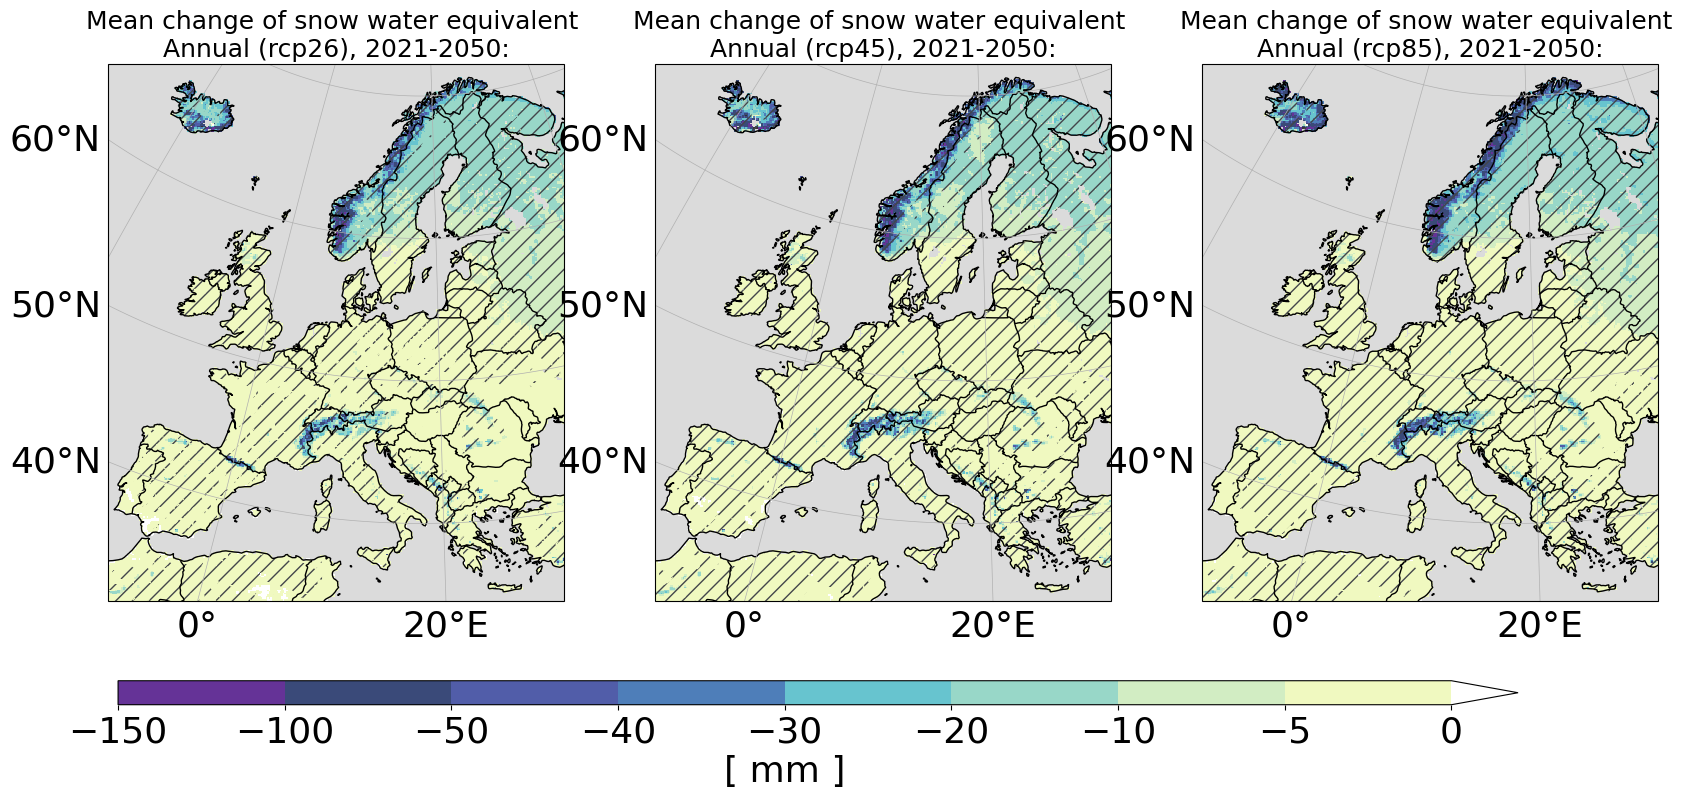

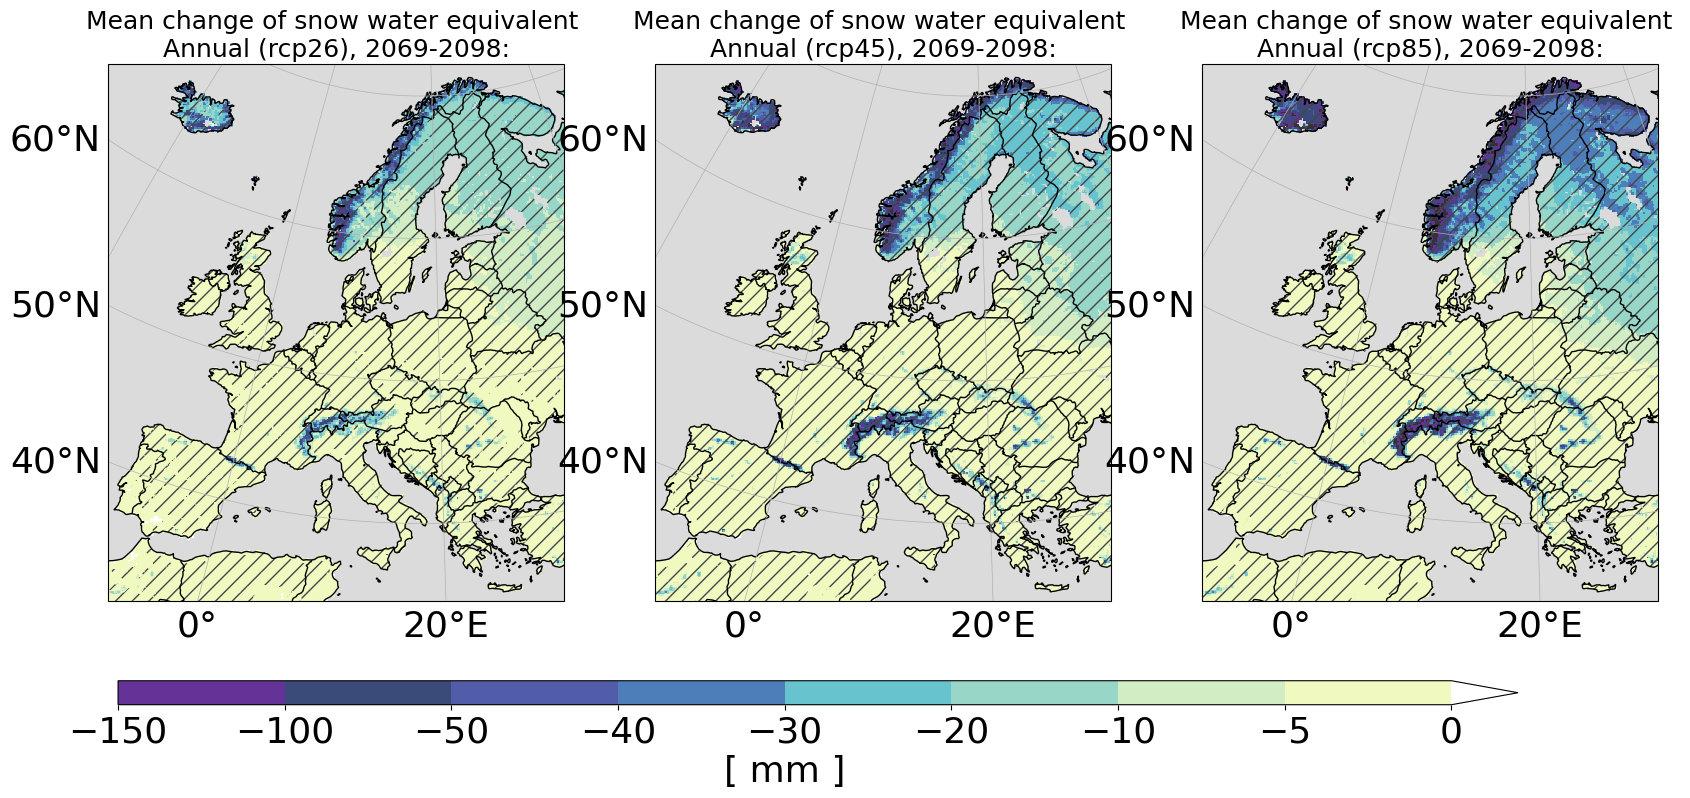

In [24]:
# plot3 for diff:
# editing the variable you like to plot 
# is needed in the line below. 
# You can choose between "snw_ensemble_diff" and "sd_ensemble_diff"

if var =='snw':
    vardiff="snw_ensemble_diff"
    unit='[ mm ]'
elif var =='sd':
    vardiff="sd_ensemble_diff"
    unit='[ days / year ]'

for timeslice in ('2022_2051', '2070_2099'):
    file1=outdatadir+'/ENS_ROBUSTNESS_'+timeslice+'_rcp26.nc'
    file2=outdatadir+'/ENS_ROBUSTNESS_'+timeslice+'_rcp45.nc'
    file3=outdatadir+'/ENS_ROBUSTNESS_'+timeslice+'_rcp85.nc'
    ds1 = xr.open_mfdataset(file1, decode_times=False)
    ds2 = xr.open_mfdataset(file2, decode_times=False)
    ds3 = xr.open_mfdataset(file3, decode_times=False)
    if timeslice == '2022_2051':
        time=timeslice.replace('2022_2051','2021-2050')
    else:
        time=timeslice.replace('2070_2099','2069-2098')
    print(time)
    ds_dict = {
    "rcp26_"+time: ds1,   
    "rcp45_"+time: ds2,    
    "rcp85_"+time: ds3,
        }
    
    plot_3(
        ds_dict,
        var=vardiff,
        unit=unit,
        mode="diff",
        colors=colors_diff_cmap,
        levels=level_steps_diff,
        robustness=True,
        add_cbar=True,
        # black hatchcolor="#020202"
        hatchcolor="#43464B",
        output_path=plotdir,
        extend="max",
    )

1971-2000
Plot saved: /work/ch0636/g300047/SNOW-RESEARCH/HORIZONTAL/plots/HORIZONTAL-SNW//ensemble_mean_absolut_snw_1971-2000.png
2021-2050
Plot saved: /work/ch0636/g300047/SNOW-RESEARCH/HORIZONTAL/plots/HORIZONTAL-SNW//ensemble_mean_absolut_snw_2021-2050.png
2069-2098
Plot saved: /work/ch0636/g300047/SNOW-RESEARCH/HORIZONTAL/plots/HORIZONTAL-SNW//ensemble_mean_absolut_snw_2069-2098.png


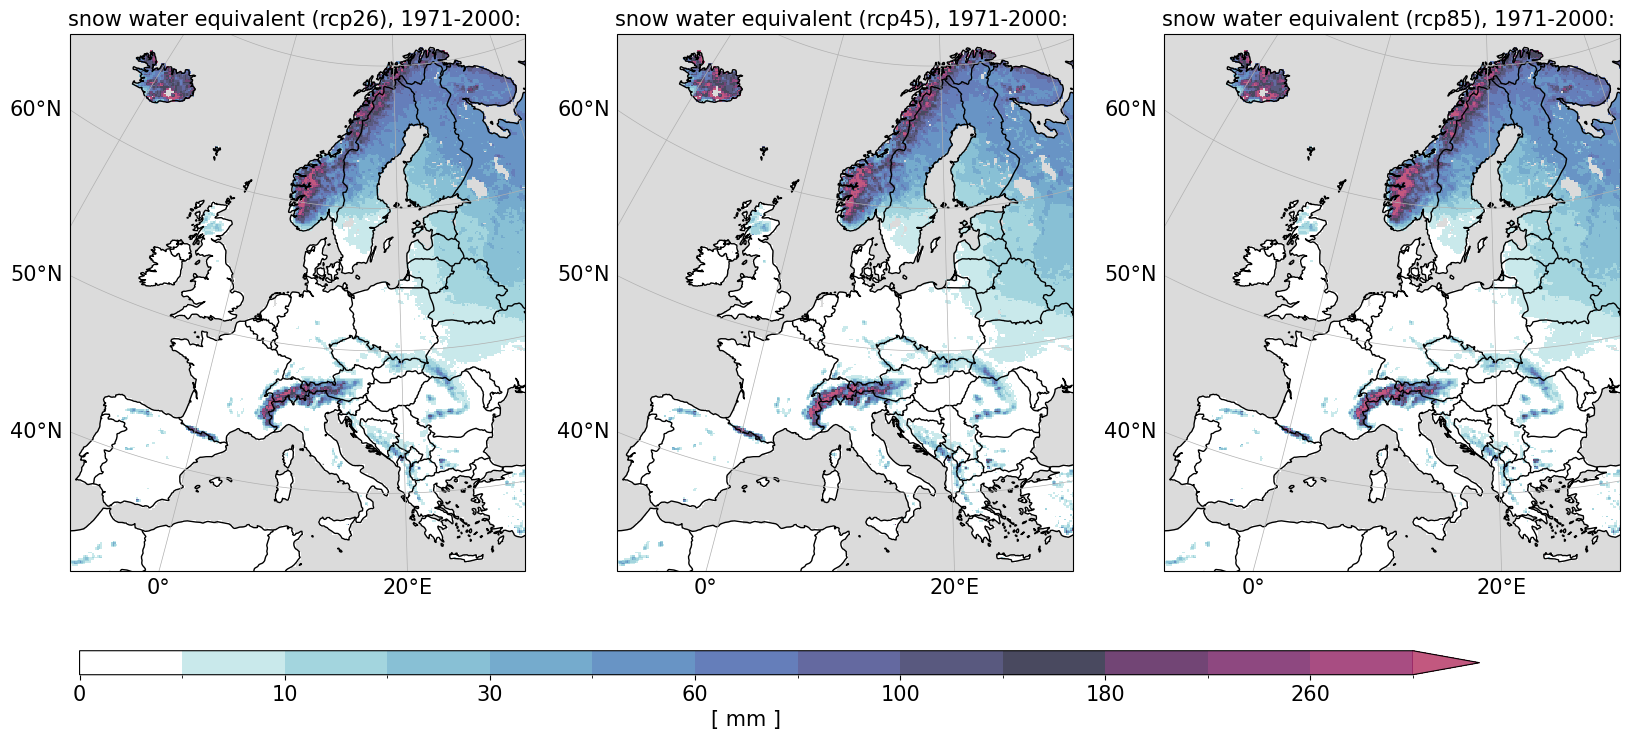

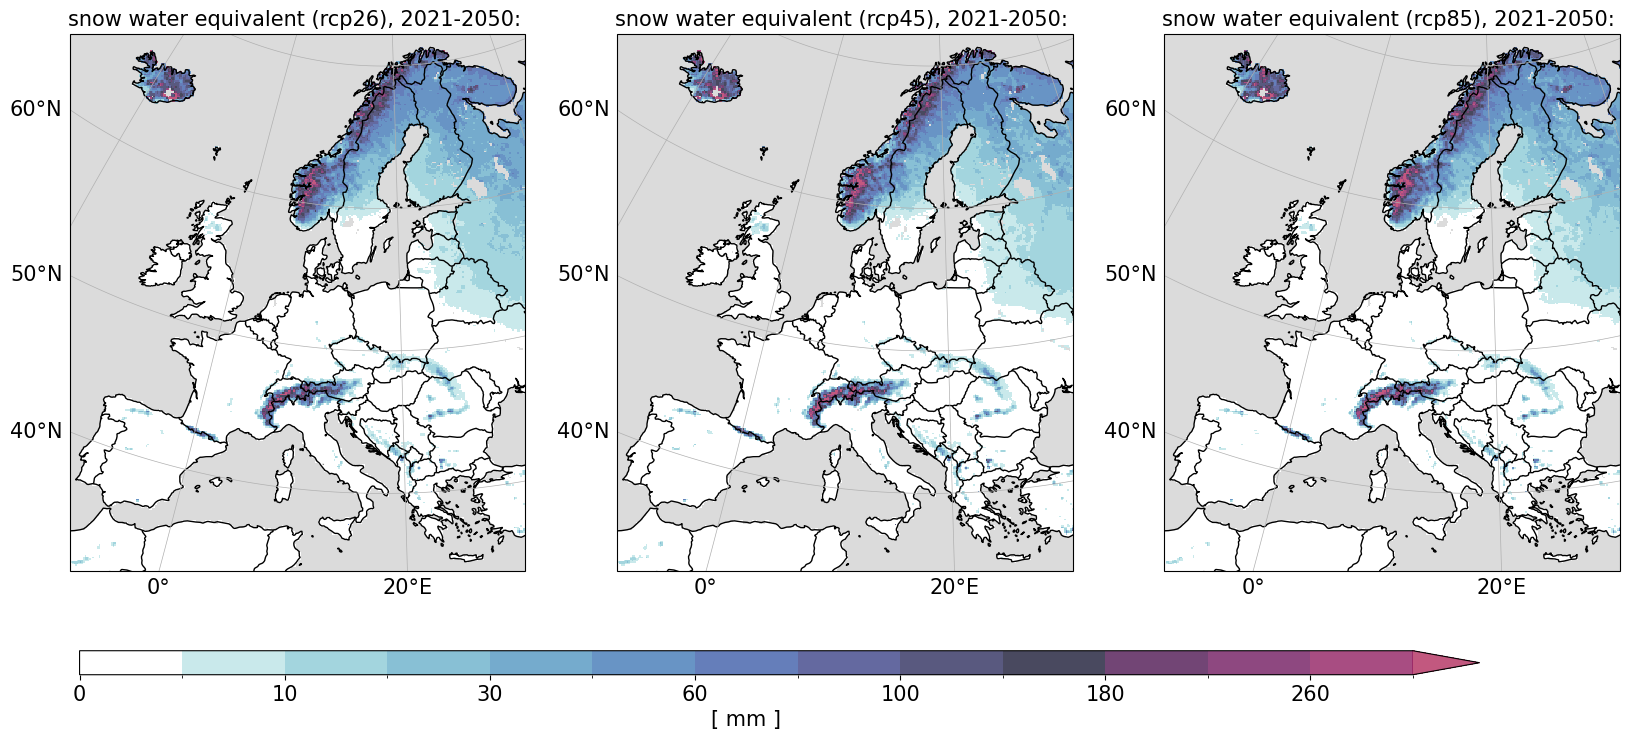

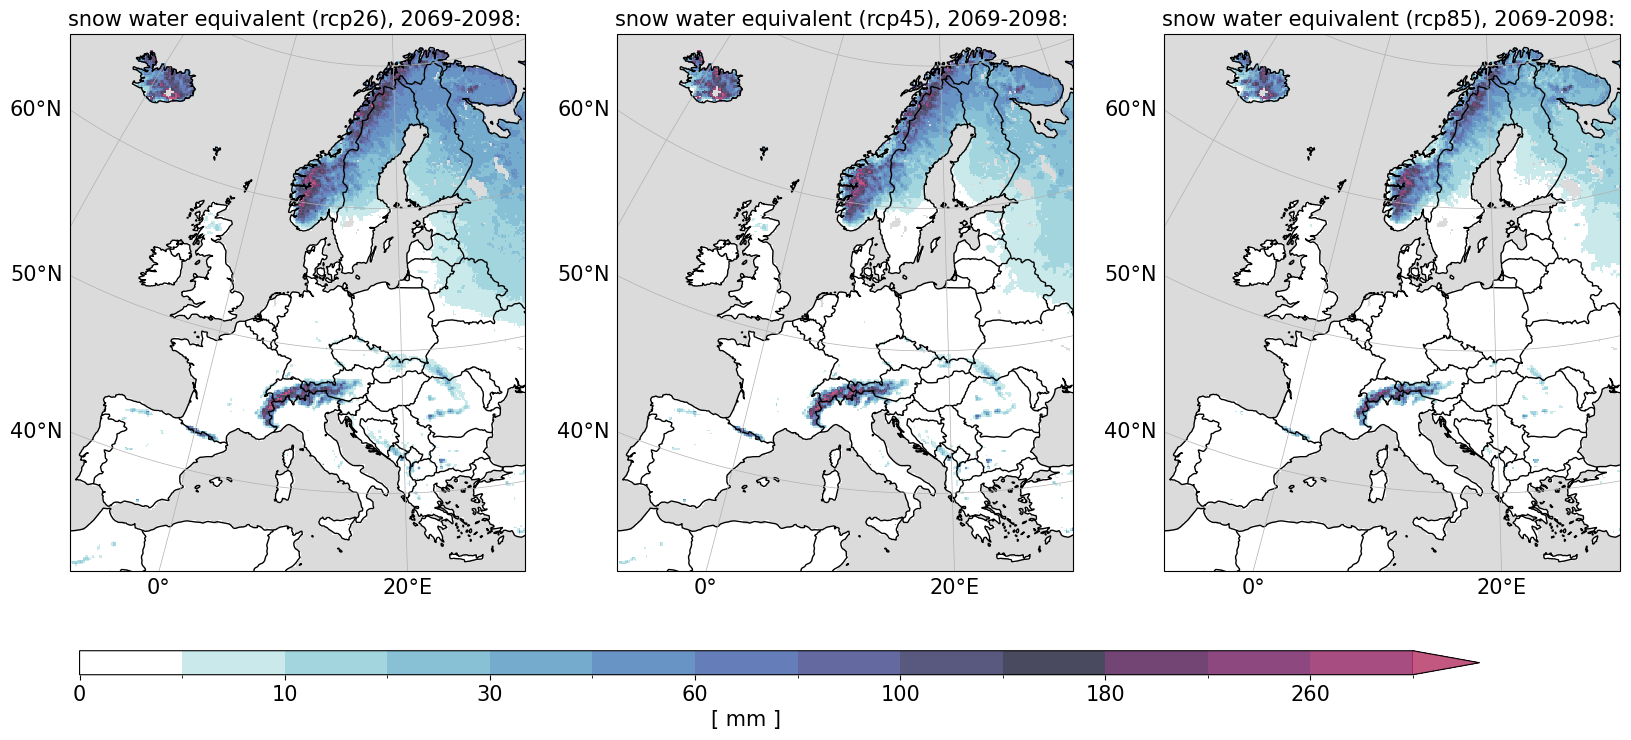

In [14]:
#plot 3 for absolut:
if var =='snw':
    unit='[ mm ]'
    colorsteps=levels_cm_swe["cm"]
    levelsteps=levels_cm_swe["levels"]
elif var =='sd':
    unit='[ days / year ]'
    colorsteps=color_steps
    levelsteps=level_steps

for timeslice in ('1972_2001', '2022_2051', '2070_2099'):
    file1=outdatadir+'/ENS_MEAN_'+timeslice+'_rcp26.nc'
    file2=outdatadir+'/ENS_MEAN_'+timeslice+'_rcp45.nc'
    file3=outdatadir+'/ENS_MEAN_'+timeslice+'_rcp85.nc'
    ds1 = xr.open_mfdataset(file1, decode_times=False)
    ds2 = xr.open_mfdataset(file2, decode_times=False)
    ds3 = xr.open_mfdataset(file3, decode_times=False)
    if timeslice == '1972_2001':
        time=timeslice.replace('1972_2001','1971-2000')
    elif timeslice == '2022_2051':
        time=timeslice.replace('2022_2051','2021-2050')
    else:
        time=timeslice.replace('2070_2099','2069-2098')
    print(time)
    ds_dict = {
    "rcp26_"+time: ds1,
    "rcp45_"+time: ds2,
    "rcp85_"+time: ds3,
        }
    #ds_dict
    plot_3(
        ds_dict,
        var=var,
        mode="absolut",
        unit=unit,
        #colors=levels_cm_swe["cm"],
        #levels=levels_cm_swe["levels"],
        colors=colorsteps,
        levels=levelsteps,
        robustness=False,
        add_cbar=True,
        # black hatchcolor="#020202"
        hatchcolor="#43464B",
        output_path=plotdir,
        extend="max",
    )

In [20]:
file4=outdatadir+'/ENS_ROBUSTNESS_2022_2051_rcp26.nc'
file5=outdatadir+'/ENS_ROBUSTNESS_2022_2051_rcp45.nc'
file6=outdatadir+'/ENS_ROBUSTNESS_2022_2051_rcp85.nc'
file7=outdatadir+'/ENS_ROBUSTNESS_2070_2099_rcp26.nc'
file8=outdatadir+'/ENS_ROBUSTNESS_2070_2099_rcp45.nc'
file9=outdatadir+'/ENS_ROBUSTNESS_2070_2099_rcp85.nc'
ds4 = xr.open_mfdataset(file4, decode_times=False)
ds5 = xr.open_mfdataset(file5, decode_times=False)
ds6 = xr.open_mfdataset(file6, decode_times=False)
ds7 = xr.open_mfdataset(file7, decode_times=False)
ds8 = xr.open_mfdataset(file8, decode_times=False)
ds9 = xr.open_mfdataset(file9, decode_times=False)
ds_dict3 = {
    "rcp26_2021-2050": ds4,
    "rcp45_2021-2050": ds5,
    "rcp85_2021-2050": ds6,
        }

ds_dict3["rcp26_2069-2098"] = ds7
ds_dict3["rcp45_2069-2098"] = ds8
ds_dict3["rcp85_2069-2098"] = ds9

<module 'matplotlib.pyplot' from '/work/ch0636/g300047/.conda/envs/snow/lib/python3.13/site-packages/matplotlib/pyplot.py'>

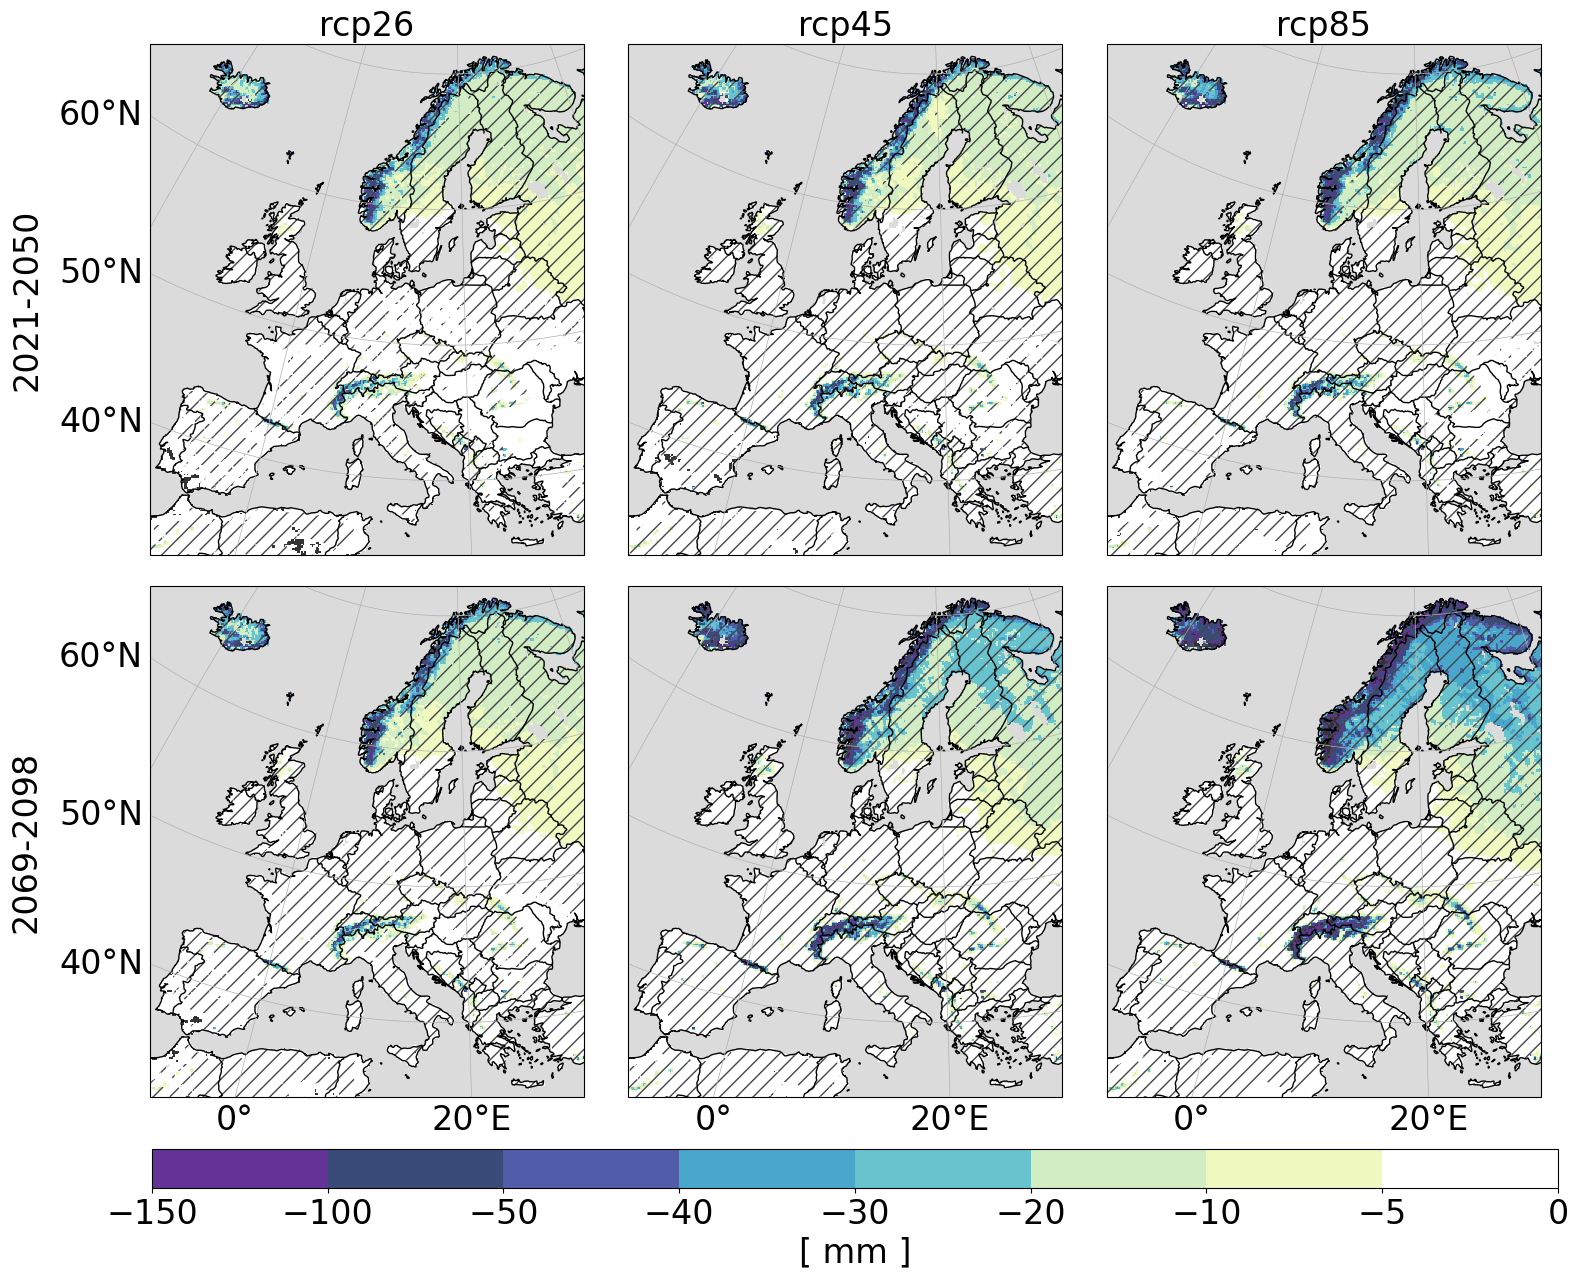

In [21]:
if var =='snw':
    vardiff="snw_ensemble_diff"
    unit='[ mm ]'
    colors_diff_cmap=colors_snw_diff_cmap
    level_steps_diff=level_snw_steps_diff
elif var =='sd':
    vardiff="sd_ensemble_diff"
    unit='[ days / year ]'
    colors_diff_cmap=colors_diff_cmap
    level_steps_diff=level_steps_diff

plot_6(
    ds_dict3,
    var=vardiff,
    mode="diff",
    colors=colors_diff_cmap,
    levels=level_steps_diff,
    robustness=True,
    add_cbar=True,
        # black hatchcolor="#020202"
    hatchcolor="#43464B",
    output_path=plotdir,
    extend="neither",
    )

In [23]:
file1=outdatadir+'/ENS_MEAN_1972_2001_rcp26.nc'
file2=outdatadir+'/ENS_MEAN_1972_2001_rcp45.nc'
file3=outdatadir+'/ENS_MEAN_1972_2001_rcp85.nc'
file4=outdatadir+'/ENS_MEAN_2022_2051_rcp26.nc'
file5=outdatadir+'/ENS_MEAN_2022_2051_rcp45.nc'
file6=outdatadir+'/ENS_MEAN_2022_2051_rcp85.nc'
file7=outdatadir+'/ENS_MEAN_2070_2099_rcp26.nc'
file8=outdatadir+'/ENS_MEAN_2070_2099_rcp45.nc'
file9=outdatadir+'/ENS_MEAN_2070_2099_rcp85.nc'
ds1 = xr.open_mfdataset(file1, decode_times=False)
ds2 = xr.open_mfdataset(file2, decode_times=False)
ds3 = xr.open_mfdataset(file3, decode_times=False)
ds4 = xr.open_mfdataset(file4, decode_times=False)
ds5 = xr.open_mfdataset(file5, decode_times=False)
ds6 = xr.open_mfdataset(file6, decode_times=False)
ds7 = xr.open_mfdataset(file7, decode_times=False)
ds8 = xr.open_mfdataset(file8, decode_times=False)
ds9 = xr.open_mfdataset(file9, decode_times=False)
ds_dict2 = {
    "rcp26_1971-2000": ds1,
    "rcp45_1971-2000": ds2,
    "rcp85_1971-2000": ds3,
        }
ds_dict2["rcp26_2021-2050"] = ds4
ds_dict2["rcp45_2021-2050"] = ds5
ds_dict2["rcp85_2021-2050"] = ds6
ds_dict2["rcp26_2069-2098"] = ds7
ds_dict2["rcp45_2069-2098"] = ds8
ds_dict2["rcp85_2069-2098"] = ds9

Plot saved: /work/ch0636/g300047/SNOW-RESEARCH/HORIZONTAL/plots/HORIZONTAL-SNW-test//ensemble_mean_snw_all_oTT.png


<module 'matplotlib.pyplot' from '/work/ch0636/g300047/.conda/envs/snow/lib/python3.13/site-packages/matplotlib/pyplot.py'>

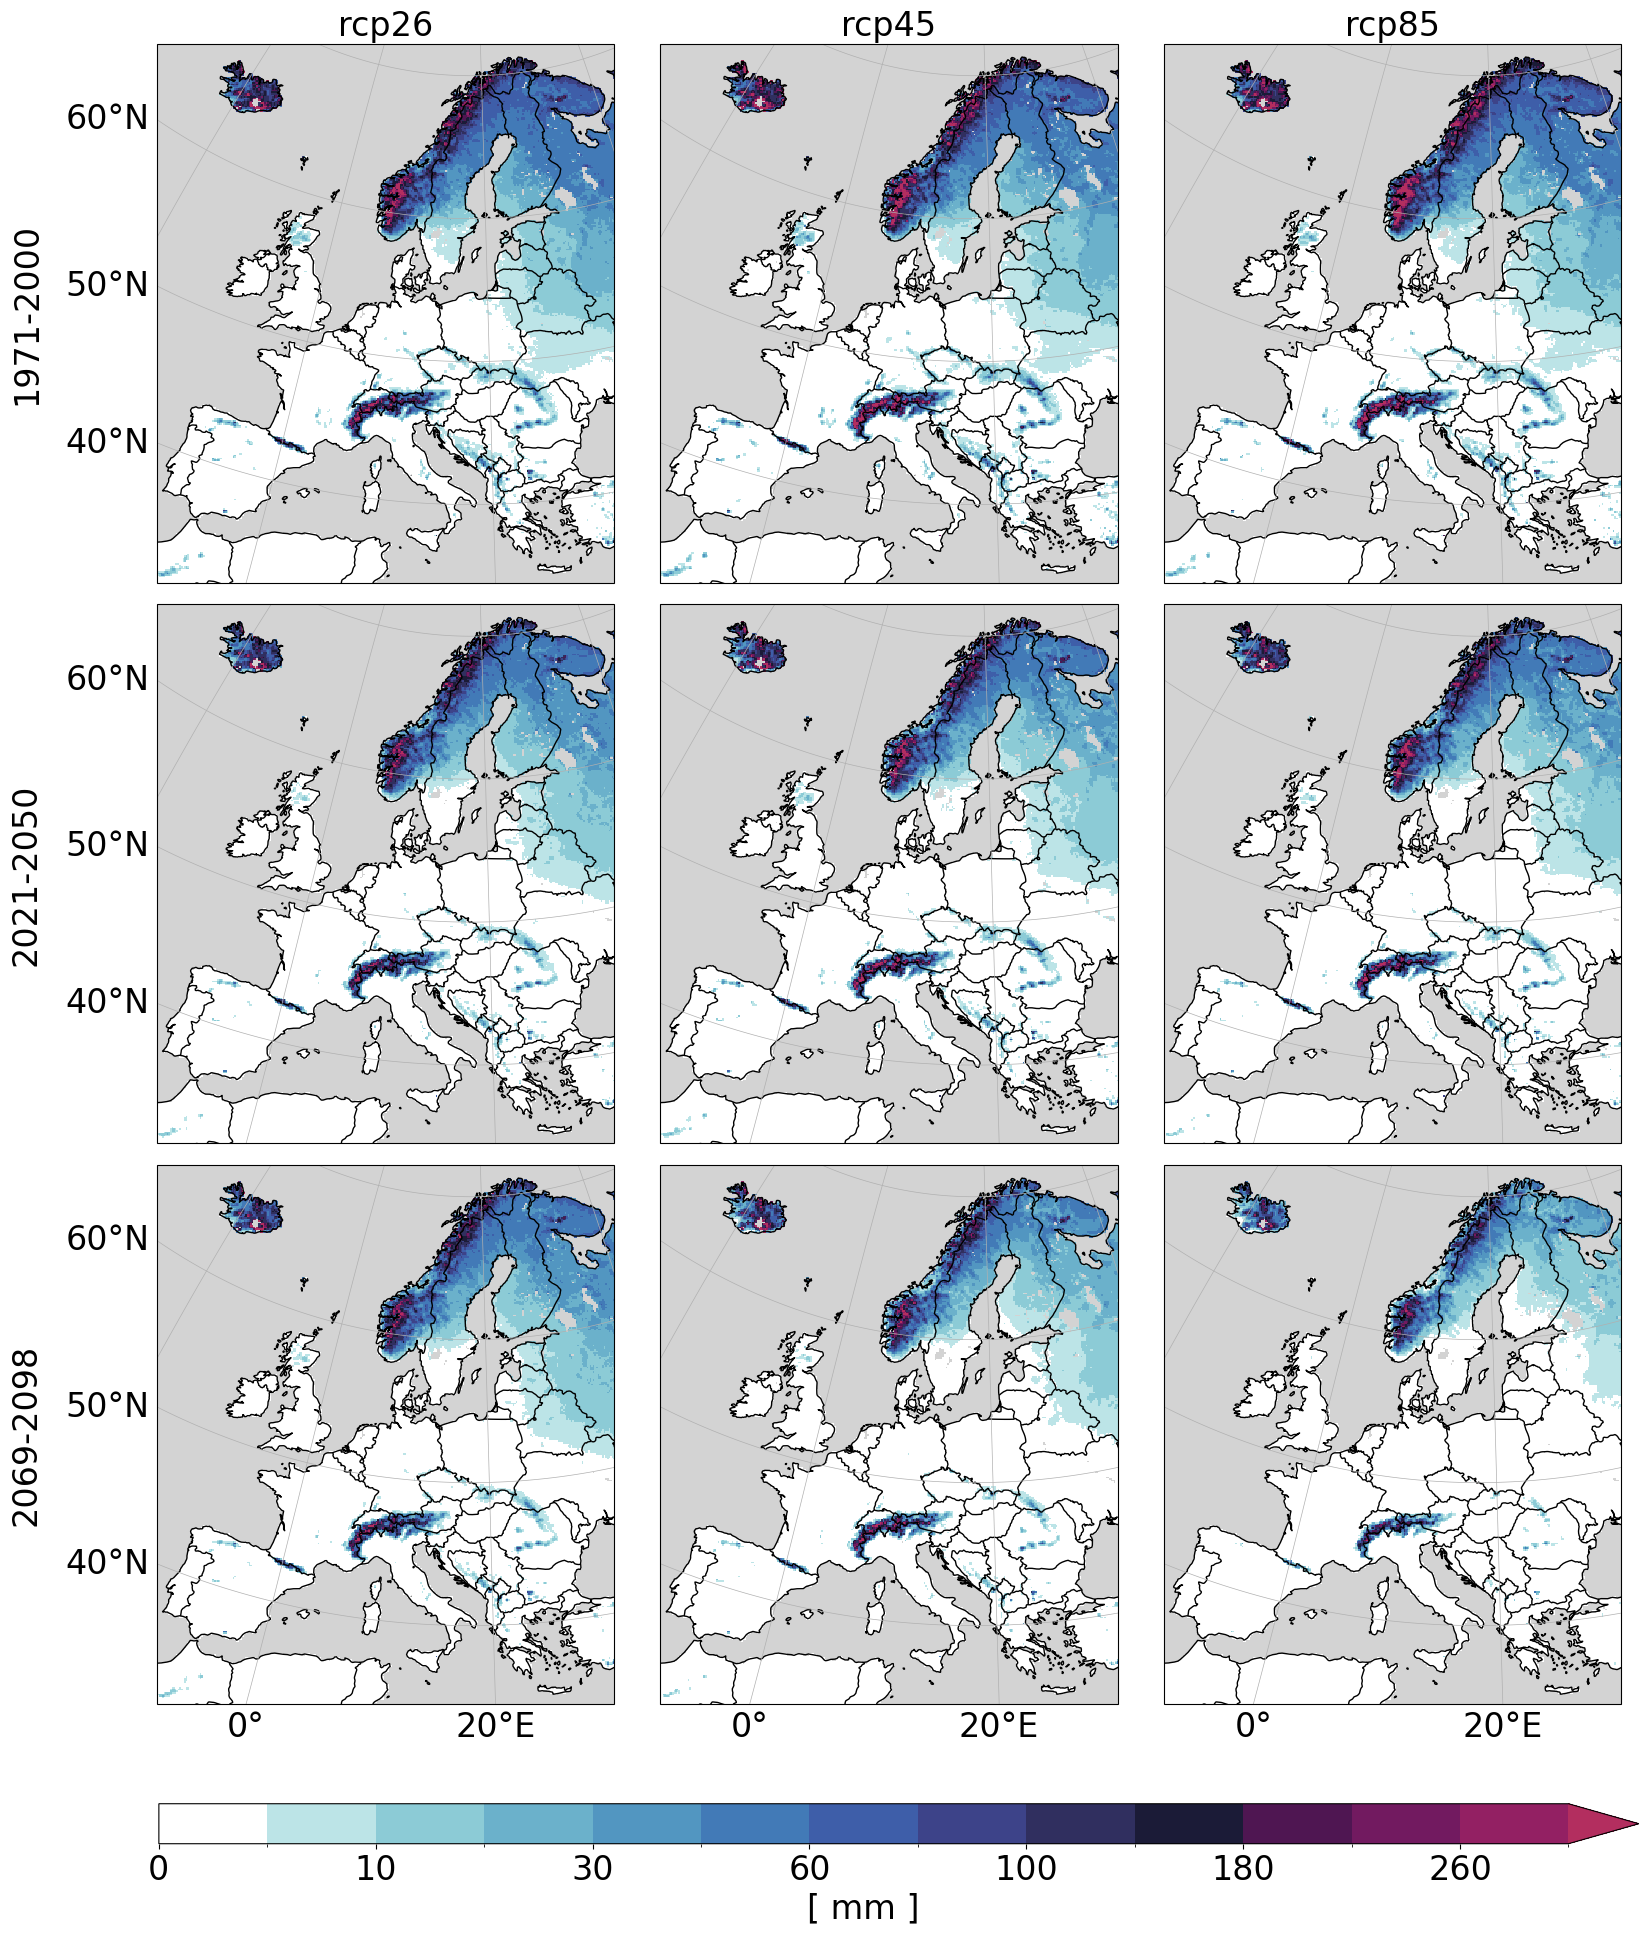

In [24]:
if var =='snw':
    colorsteps=levels_cm_swe["cm"]
    levelsteps=levels_cm_swe["levels"]
elif var == 'sd':
    colorsteps=color_steps
    levelsteps=level_steps

plot_9(
    ds_dict2,
    var=var,
    mode="absolut",
    #colors=levels_cm_swe["cm"],
    #levels=levels_cm_swe["levels"],
    colors=colorsteps,
    levels=levelsteps,
    #robustness=False,
    add_cbar=True,
    #hatchcolor="#43464B",
    output_path=plotdir,
    extend="max",
    )
